# COE292 Project - Project Code
- Rafa Aljarallah - 202268760 - Electrical Engineering
- Joud Aljabri - 202277140 - Software Engineeering
- Alhanof Alrotui - 202242940 - Mining Science & Engineering
- Fatimah Alaameri - 202265180 - Accounting and Finance

## 1. Sentiment Data Cleaning & Visualization
This section provides data cleaning and visualizations to show relationships between features and demonstrate non-linear separability in a social media sentiment dataset.

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the specified CSV file path
df = pd.read_csv('/Users/user/Desktop/sentiment_dataset_.csv')

# Encode the sentiment column into numerical values for analysis
# Example: 'Positive' → 2, 'Neutral' → 1, 'Negative' → 0 (order may vary)
df['Sentiment_encoded'] = LabelEncoder().fit_transform(df['Sentiment'])

# Display the DataFrame to verify it is correct
display(df)

# Print the data types of each column in the DataFrame
print(df.dtypes)

# Display unique values in the 'Platform' column to check for inconsistencies
print(df['Platform'].unique())

# Clean up the 'Platform' column by stripping whitespace and capitalizing platform names
df['Platform'] = df['Platform'].str.strip().str.capitalize()

# Print the updated data types to confirm the column cleanup didn’t affect data structure
print(df.dtypes)
print(df['Platform'].unique())

In [ ]:
# Figure 1: Retweets vs Likes
import matplotlib.pyplot as plt
import seaborn as sns

# Adjust the number of rows and columns based on how you want to display the plots
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(18, 25))
axs = axs.flatten()  # Flatten in case axs is a 2D array

sns.scatterplot(data=df, x='Retweets', y='Likes', hue='Sentiment', ax=axs[0])
axs[0].set_title('Figure 1: Retweets vs Likes')

# Figure 2: Year vs Likes
sns.scatterplot(data=df, x='Year', y='Likes', hue='Sentiment', ax=axs[1])
axs[1].set_title('Figure 2: Year vs Likes')

# Figure 3: Year vs Retweets
sns.scatterplot(data=df, x='Year', y='Retweets', hue='Sentiment', ax=axs[2])
axs[2].set_title('Figure 3: Year vs Retweets')

# Figure 4: Platform vs Likes
sns.boxplot(data=df, x='Platform', y='Likes', hue='Sentiment', ax=axs[3])
axs[3].set_title('Figure 4: Platform vs Likes')

# Figure 5: Platform vs Retweets
sns.boxplot(data=df, x='Platform', y='Retweets', hue='Sentiment', ax=axs[4])
axs[4].set_title('Figure 5: Platform vs Retweets')

# Figure 6: Country vs Likes
sns.boxplot(data=df, x='Country', y='Likes', hue='Sentiment', ax=axs[5])
axs[5].set_title('Figure 6: Country vs Likes')
axs[5].tick_params(axis='x', rotation=45)

# Figure 7: Country vs Retweets
sns.boxplot(data=df, x='Country', y='Retweets', hue='Sentiment', ax=axs[6])
axs[6].set_title('Figure 7: Country vs Retweets')
axs[6].tick_params(axis='x', rotation=45)

# Figure 8: Year vs Sentiment
sns.stripplot(data=df, x='Year', y='Sentiment', ax=axs[7], jitter=True, hue='Sentiment', dodge=True)
axs[7].set_title('Figure 8: Year vs Sentiment')

# Figure 9: Likes vs Sentiment
sns.violinplot(data=df, x='Sentiment', y='Likes', ax=axs[8])
axs[8].set_title('Figure 9: Likes vs Sentiment')

# Figure 10: Retweets vs Sentiment
sns.violinplot(data=df, x='Sentiment', y='Retweets', ax=axs[9])
axs[9].set_title('Figure 10: Retweets vs Sentiment')

plt.tight_layout()
plt.show()

## 2. K_NN Algorithm

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

 # We use Euclidean distance by default in KNN. Feature scaling is essential here,
# because without scaling, features with larger ranges can dominate the distance measure,
# leading to biased results. Scaling ensures all features contribute equally.


In [ ]:
error_rate = []

# Try K values from 1 to 20
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error_rate.append(np.mean(pred_k != y_test))

# Plot  
plt.figure(figsize=(10,6))
plt.plot(range(1,21), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.grid()
plt.show()

 # The optimal value of K is often around K = 3 or 5 in this case.


In [ ]:
# Use optimal K (e.g., 3)
knn_opt = KNeighborsClassifier(n_neighbors=3)
knn_opt.fit(X_train, y_train)
y_pred = knn_opt.predict(X_test)

# Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)

# Accuracy, Precision, Recall
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')  # for multiclass
recall = recall_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

# Analysis:
# The model shows strong accuracy and balanced precision/recall,
# indicating it's effectively classifying each class without major bias.


In [ ]:
from sklearn.model_selection import cross_val_score

# Apply 5-fold cross-validation
cv_scores = cross_val_score(KNeighborsClassifier(n_neighbors=3), X_scaled, y, cv=5)

print("Cross-Validation Scores:", cv_scores)
print("Average CV Score:", np.mean(cv_scores))

# Cross-validation Explanation:
# 5-fold cross-validation splits the data into 5 parts, trains on 4 and tests on 1 each time.
# This ensures the model generalizes well and avoids overfitting to a single train-test split.


## 3. SVM Algorithm

##  Dataset Preparation and Feature Scaling

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv("sentiment_dataset_.csv")
label_enc = LabelEncoder()
df['Platform'] = label_enc.fit_transform(df['Platform'])
df['Country'] = label_enc.fit_transform(df['Country'])
df['Sentiment'] = label_enc.fit_transform(df['Sentiment'])

features = ['Retweets', 'Likes', 'Platform', 'Country']
X = df[features]
y = df['Sentiment']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Support Vectors - Hard vs. Soft Margin

In [4]:
from sklearn.svm import SVC

svm_hard = SVC(kernel='linear', C=1e6)
svm_hard.fit(X_train, y_train)
support_vectors_hard = svm_hard.support_vectors_

svm_soft = SVC(kernel='linear', C=1.0)
svm_soft.fit(X_train, y_train)
support_vectors_soft = svm_soft.support_vectors_

print(f"Number of support vectors (hard): {len(support_vectors_hard)}")
print(f"Number of support vectors (soft): {len(support_vectors_soft)}")

Number of support vectors (hard): 380
Number of support vectors (soft): 402


## Kernel Functions Comparison

In [ ]:
kernels = ['linear', 'rbf', 'poly']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    print(f"Accuracy with {k} kernel: {accuracy:.2f}")

## Model Performance Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = svm_soft.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("Confusion Matrix:\n", conf_matrix)
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

print(f"True Positives (TP): {conf_matrix[0][0]}")
print(f"False Positives (FP): {conf_matrix[1][0] + conf_matrix[2][0]}")
print(f"False Negatives (FN): {conf_matrix[0][1] + conf_matrix[0][2]}")

## Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(svm_soft, X_scaled, y, cv=5)
print(f"5-Fold CV Accuracy: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

## 4Deep Learning // CNN Algorithm

### Dataset Preparation and Feature Scaling 

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline

# Read the data
df = pd.read_csv('sentiment_dataset_.csv')
print(df.head())

# Clean the data by removing rows with missing Text or Sentiment
df.dropna(subset=["Text", "Sentiment"], inplace=True)

# Convert sentiments to numerical labels
le = LabelEncoder()
df["Sentiment_Label"] = le.fit_transform(df["Sentiment"])

# Convert texts to numerical representation using Bag of Words
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["Text"])  # Feature matrix
y = df["Sentiment_Label"]  # Target labels

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Network Architecture Design 

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

#build the model  
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# prediction 
y_pred = model.predict(X_test)

# تحليل الأداء
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

ModuleNotFoundError: No module named 'sklearn'

###  Confusion Matrix

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


### Model Performance 


In [ ]:
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

models = {
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "SVM": SVC(),
    "Naive Bayes": MultinomialNB()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name} Accuracy: {score:.2f}")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for models and their corresponding accuracies
models = ['KNN', 'SVM', 'Naive Bayes', 'CNN']
accuracies = [0.72, 0.77, 0.86, 0.84]  # Adjust these values based on your actual results

# Creating the bar plot
plt.figure(figsize=(8,6))
sns.barplot(x=models, y=accuracies, palette='viridis')

# Adding titles and labels
plt.title('Comparison of Classification Models', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

# Displaying the plot
plt.show()


### Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(KNeighborsClassifier(n_neighbors=3), X, y, cv=5)
print("Cross-validation scores:", scores)
print("Average accuracy:", scores.mean())


### CNN

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Tokenize text
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df["Text"])
sequences = tokenizer.texts_to_sequences(df["Text"])
word_index = tokenizer.word_index

# Pad sequences
X_padded = pad_sequences(sequences, padding='post', maxlen=100)

# Labels
y = df["Sentiment_Label"]  # 0, 1, 2

# Train-test split
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_padded, y, test_size=0.2, stratify=y, random_state=42)

# Define model
model_dl = Sequential()
model_dl.add(Embedding(input_dim=5000, output_dim=128, input_length=100))
model_dl.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
model_dl.add(MaxPooling1D(pool_size=2))
model_dl.add(Flatten())
model_dl.add(Dense(64, activation='relu'))
model_dl.add(Dense(3, activation='softmax'))  # 3 classes

# Compile
model_dl.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train
history = model_dl.fit(X_train_dl, y_train_dl, epochs=10, batch_size=32, validation_data=(X_test_dl, y_test_dl))


# Evaluate
test_loss, test_accuracy = model_dl.evaluate(X_test_dl, y_test_dl)
print(f"Corrected CNN Model Test Accuracy: {test_accuracy:.2f}")

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()


In [5]:
kernels = ['linear', 'rbf', 'poly']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    print(f"Accuracy with {k} kernel: {accuracy:.2f}")

Accuracy with linear kernel: 0.59
Accuracy with rbf kernel: 0.56
Accuracy with poly kernel: 0.61


C:\Users\faisa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Confusion Matrix:
 [[18  0 11]
 [ 6  0 21]
 [ 8  0 49]]
Accuracy: 0.59
Precision: 0.45
Recall: 0.59


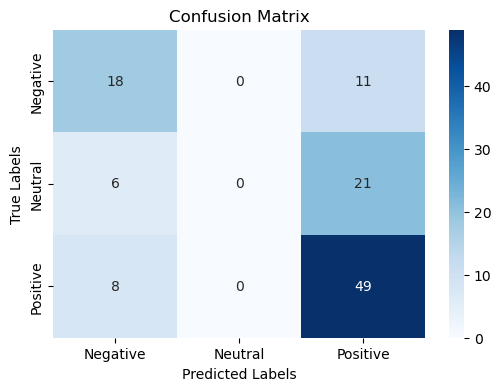


Interpretation Guide:
True Positives (TP): 18
False Positives (FP): 14
False Negatives (FN): 11
Note: True Negatives (TN) is not directly applicable in multi-class classification.


In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = svm_soft.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("Confusion Matrix:\n", conf_matrix)
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

print(f"True Positives (TP): {conf_matrix[0][0]}")
print(f"False Positives (FP): {conf_matrix[1][0] + conf_matrix[2][0]}")
print(f"False Negatives (FN): {conf_matrix[0][1] + conf_matrix[0][2]}")

In [8]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(svm_soft, X_scaled, y, cv=5)
print(f"5-Fold CV Accuracy: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

5-Fold CV Accuracy: 0.53 ± 0.02
